In [10]:
import pandas as pd
import json

# 2. Convert the text into a Python list
lokdata = json.load(open("Lok.json"))

# 3. Create the DataFrame
df = pd.DataFrame(lokdata)

# 4. Save it so you never have to paste it again
df.to_csv("lokawaz_final_data.csv", index=False)

print("Data saved! You have", len(df), "rows to analyze.")
print(df.columns)

Data saved! You have 92 rows to analyze.
Index(['id', 'date', 'source', 'headline', 'category', 'sentiment', 'city',
       'party', 'tags', 'state', 'politician', 'votes_up', 'votes_down',
       'bias_score', 'user_engagement_score', 'trending_score', 'top_comment',
       'summary'],
      dtype='object')


In [11]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data we just saved
df = pd.read_csv("lokawaz_final_data.csv")

# Function to calculate Polarity
def get_analysis(text):
    return TextBlob(text).sentiment.polarity

# Apply the engine to the 'headline' column
df['calculated_score'] = df['headline'].apply(get_analysis)

# Categorize the calculated score
df['model_sentiment'] = df['calculated_score'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)

# See how often our model agrees with the data labels!
agreement = (df['sentiment'] == df['model_sentiment']).mean() * 100
print(f"Model Agreement Rate: {agreement:.2f}%")

Model Agreement Rate: 26.09%


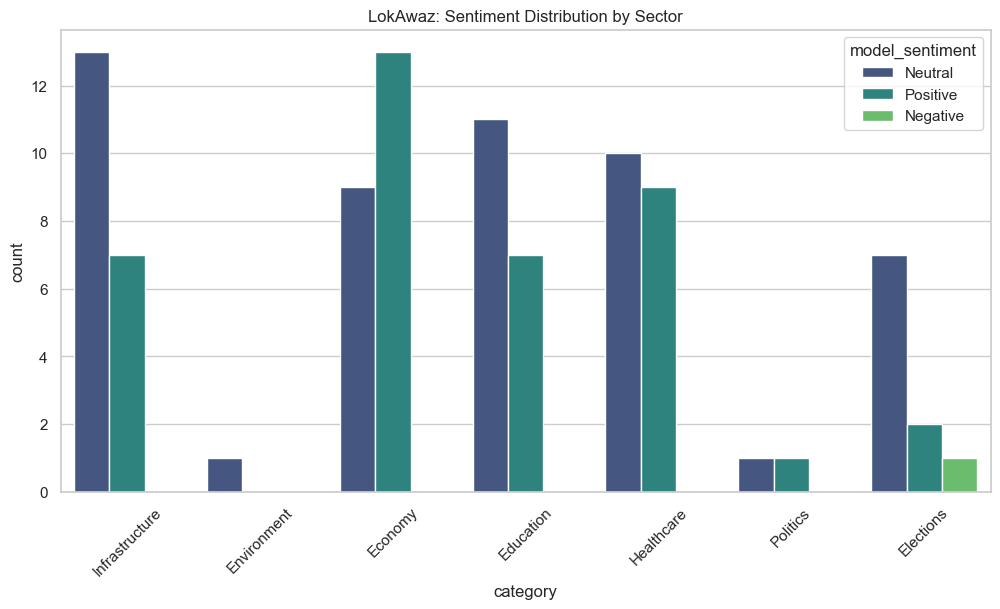

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='category', hue='model_sentiment', palette='viridis')
plt.title('LokAwaz: Sentiment Distribution by Sector')
plt.xticks(rotation=45)
plt.show()

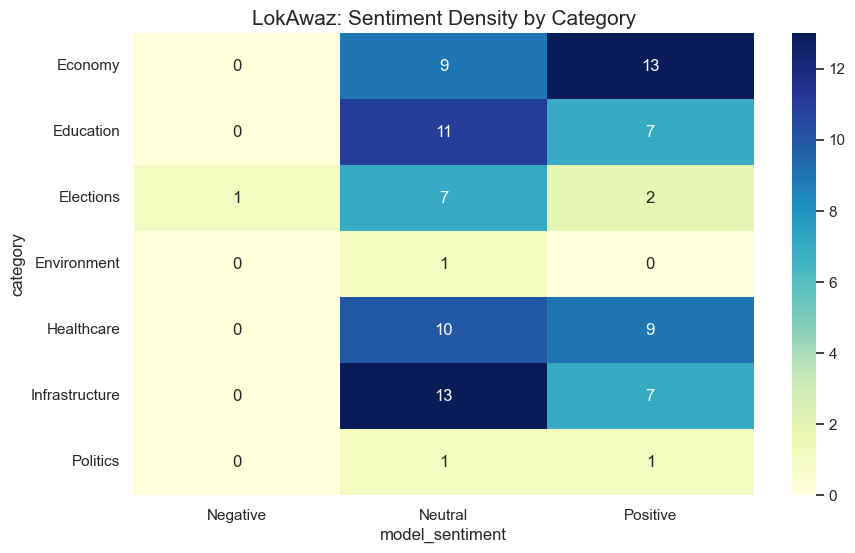

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a cross-tabulation of Category vs Sentiment
pivot_table = pd.crosstab(df['category'], df['model_sentiment'])

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title('LokAwaz: Sentiment Density by Category', fontsize=15)
plt.show()

C:\Users\bevic\AppData\Local\Temp\ipykernel_1976\1573933203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='party', y='calculated_score', data=df, palette="Set2")


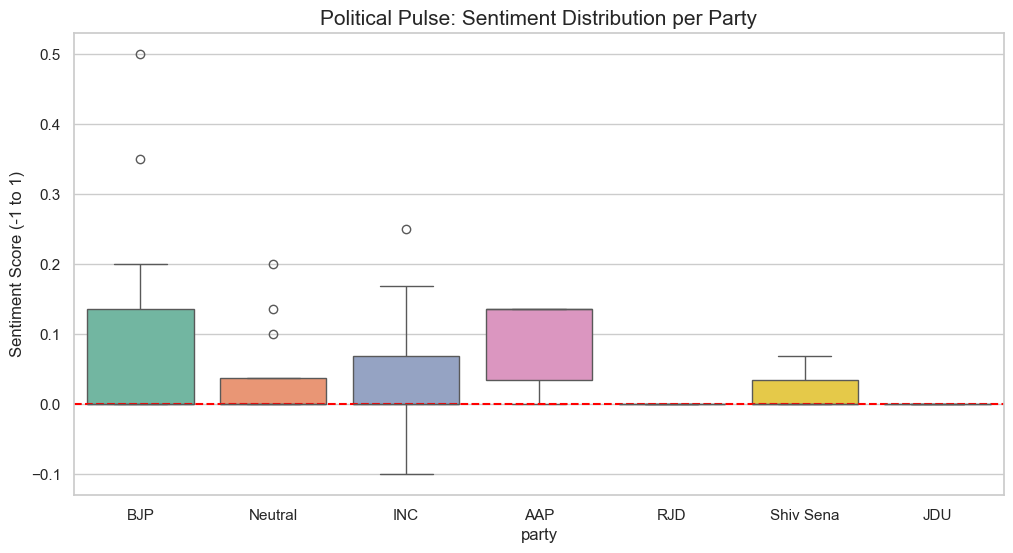

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='party', y='calculated_score', data=df, palette="Set2")
plt.axhline(0, color='red', linestyle='--') # Neutral line
plt.title('Political Pulse: Sentiment Distribution per Party', fontsize=15)
plt.ylabel('Sentiment Score (-1 to 1)')
plt.show()

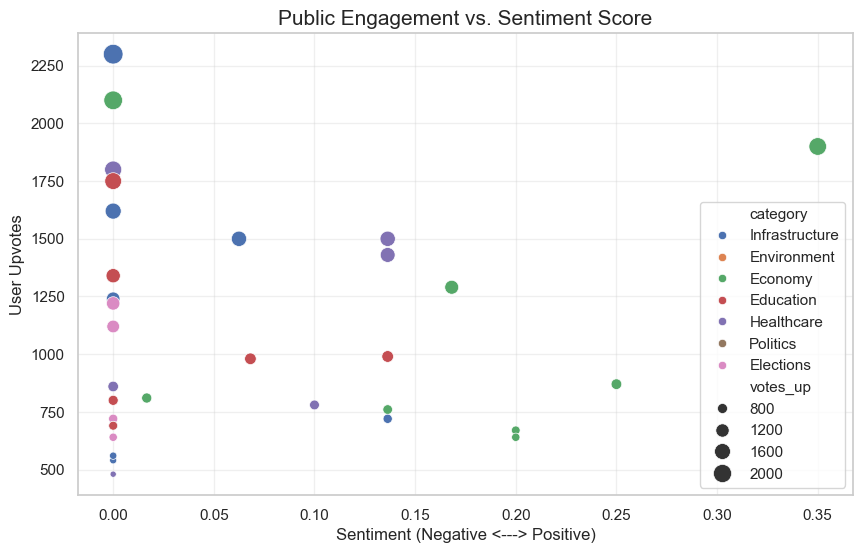

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='calculated_score', y='votes_up', hue='category', size='votes_up', sizes=(20, 200))
plt.title('Public Engagement vs. Sentiment Score', fontsize=15)
plt.xlabel('Sentiment (Negative <---> Positive)')
plt.ylabel('User Upvotes')
plt.grid(True, alpha=0.3)
plt.show()

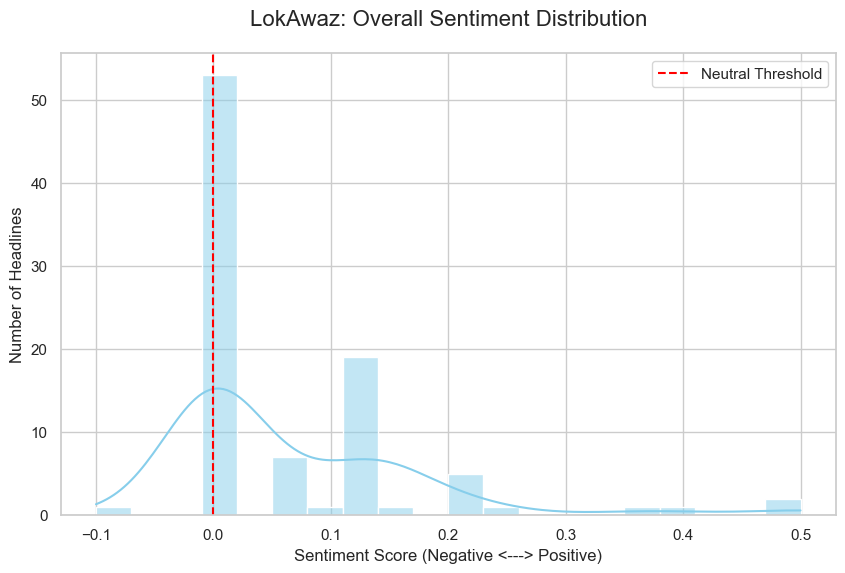

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plotting the distribution of scores
sns.histplot(df['calculated_score'], kde=True, color="skyblue", bins=20)

# Adding vertical lines for clarity
plt.axvline(0, color='red', linestyle='--', label='Neutral Threshold')
plt.title('LokAwaz: Overall Sentiment Distribution', fontsize=16, pad=20)
plt.xlabel('Sentiment Score (Negative <---> Positive)', fontsize=12)
plt.ylabel('Number of Headlines', fontsize=12)
plt.legend()
plt.show()

C:\Users\bevic\AppData\Local\Temp\ipykernel_1976\2623974591.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='calculated_score', palette="Spectral")


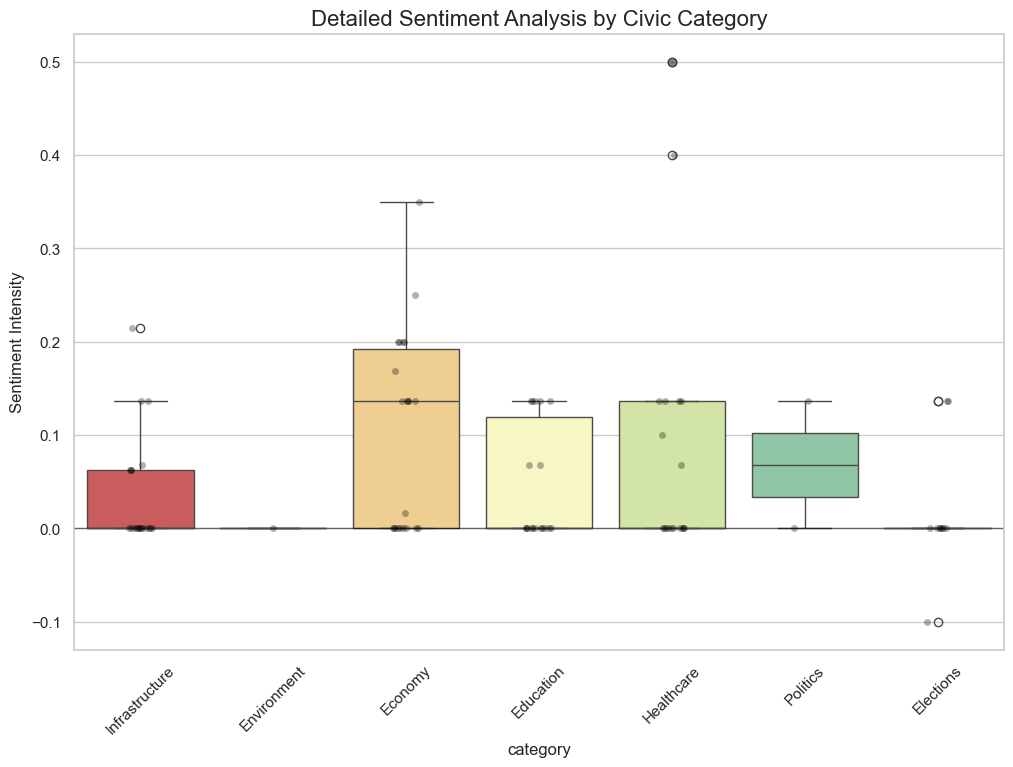

In [17]:
plt.figure(figsize=(12, 8))

# Using a Box Plot to show the 'Spread' of sentiment in each category
sns.boxplot(data=df, x='category', y='calculated_score', palette="Spectral")

# Adding individual points (stripplot) to see every single headline
sns.stripplot(data=df, x='category', y='calculated_score', color="black", alpha=0.3)

plt.title('Detailed Sentiment Analysis by Civic Category', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Sentiment Intensity', fontsize=12)
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.show()


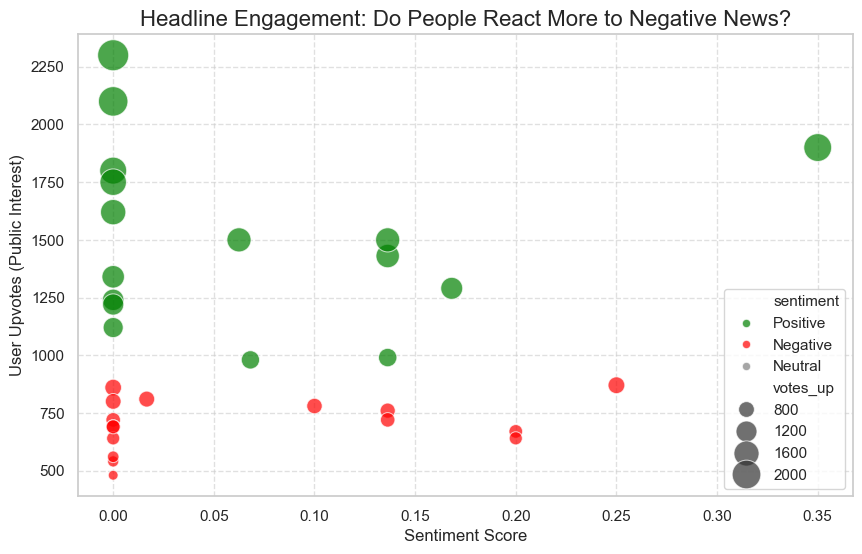

In [18]:
plt.figure(figsize=(10, 6))

# Bubble chart: Size of bubble represents engagement (Upvotes)
sns.scatterplot(data=df, x='calculated_score', y='votes_up', 
                size='votes_up', hue='sentiment', 
                sizes=(50, 500), alpha=0.7, palette={'Positive':'green', 'Negative':'red', 'Neutral':'gray'})

plt.title('Headline Engagement: Do People React More to Negative News?', fontsize=16)
plt.xlabel('Sentiment Score', fontsize=12)
plt.ylabel('User Upvotes (Public Interest)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()